In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv(
    r"C:\Users\91895\OneDrive\Desktop\NeuralRetail\data\processed\cleaned_retail.csv"
)

In [4]:
print("Shape:", df.shape)

df.head()

Shape: (805549, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805549 entries, 0 to 805548
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805549 non-null  int64  
 1   StockCode    805549 non-null  object 
 2   Description  805549 non-null  object 
 3   Quantity     805549 non-null  int64  
 4   InvoiceDate  805549 non-null  object 
 5   Price        805549 non-null  float64
 6   Customer ID  805549 non-null  float64
 7   Country      805549 non-null  object 
 8   Revenue      805549 non-null  float64
dtypes: float64(3), int64(2), object(4)
memory usage: 55.3+ MB


In [6]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
Revenue        0
dtype: int64

In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [8]:
total_revenue = df["Revenue"].sum()

print(
    f"Total Revenue: £{total_revenue:,.2f}"
)

Total Revenue: £17,743,429.18


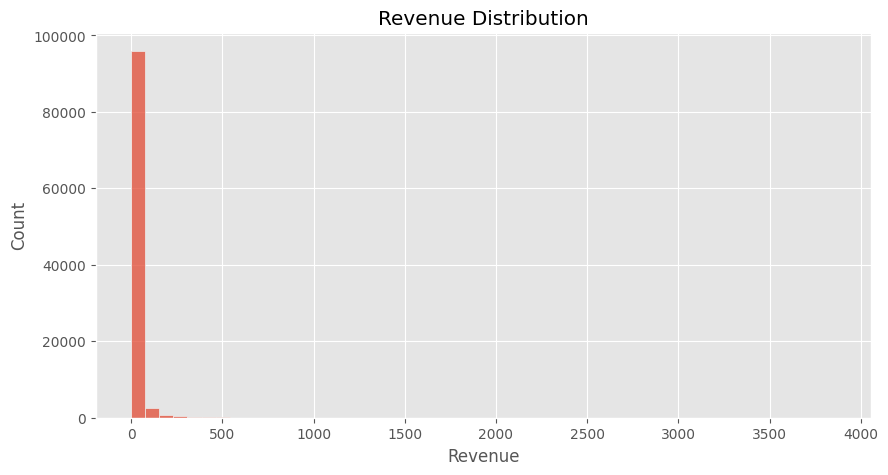

In [9]:
sample_df = df.sample(
    n=min(100000, len(df)),
    random_state=42
)

plt.figure(figsize=(10,5))

sns.histplot(
    sample_df["Revenue"],
    bins=50
)

plt.title("Revenue Distribution")

plt.show()

In [10]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

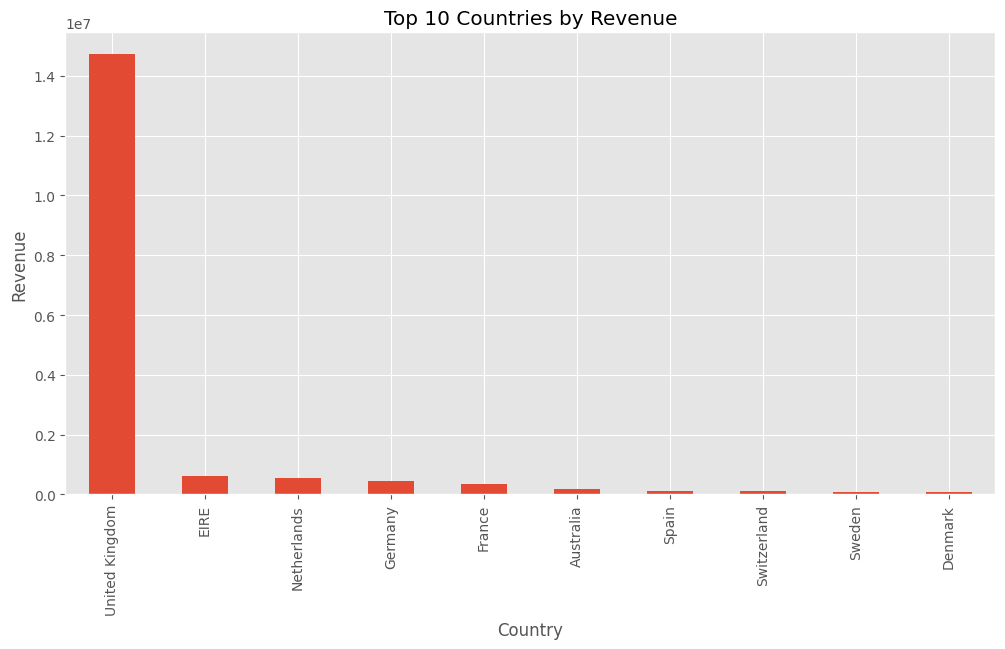

In [11]:
plt.figure(figsize=(12,6))

country_revenue.plot(kind="bar")

plt.title(
    "Top 10 Countries by Revenue")

plt.ylabel("Revenue")

plt.show()

## Key Findings

- The United Kingdom contributes the majority of total revenue.
- European countries form the strongest international customer base.
- Revenue is highly concentrated in a small number of geographic markets.
- Emerging markets provide opportunities for future growth.

In [12]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10))
top_products

Description
REGENCY CAKESTAND 3 TIER              286486.30
WHITE HANGING HEART T-LIGHT HOLDER    252072.46
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                152340.57
JUMBO BAG RED RETROSPOT               136980.08
ASSORTED COLOUR BIRD ORNAMENT         127074.17
POSTAGE                               126563.04
PARTY BUNTING                         103880.23
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         79594.33
Name: Revenue, dtype: float64

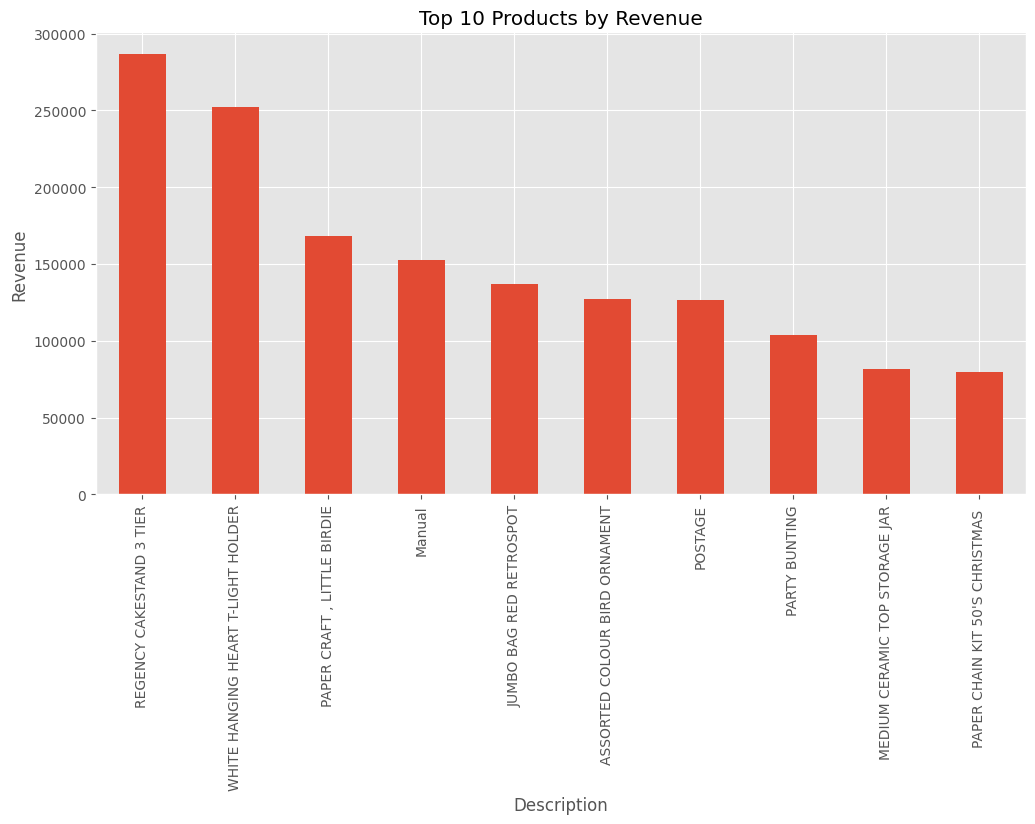

In [13]:
plt.figure(figsize=(12,6))

top_products.plot(
    kind="bar"
)

plt.title(
    "Top 10 Products by Revenue"
)

plt.ylabel("Revenue")

plt.show()

## Key Findings

- A small number of products contribute a significant portion of total revenue.
- Home décor and gifting products dominate sales.
- Seasonal products show strong revenue contribution.
- High-performing products should be prioritized for inventory planning.

# Product Analysis

Product-level analysis identifies:

- Best-selling products
- Highest revenue-generating products
- Product demand patterns

Understanding product performance supports inventory planning and marketing decisions.

In [14]:
df["Month"] = (
    df["InvoiceDate"]
    .dt.to_period("M")
)

In [15]:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
)

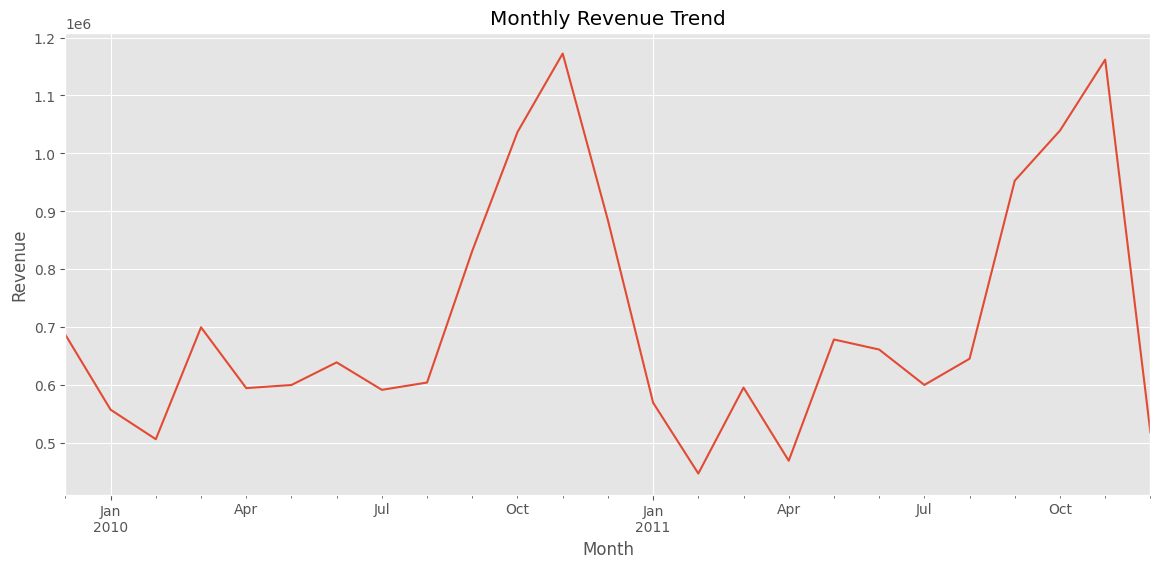

In [16]:
plt.figure(figsize=(14,6))

monthly_revenue.plot()

plt.title(
    "Monthly Revenue Trend"
)

plt.ylabel("Revenue")

plt.show()

# Monthly Revenue Trend

Time-series analysis helps identify:

- Revenue growth patterns
- Seasonal demand fluctuations
- Holiday sales peaks
- Business performance over time

These insights will later support forecasting models.

## Key Findings

- Revenue varies across months due to changing customer demand.
- Seasonal peaks indicate increased purchasing activity during specific periods.
- Understanding these patterns helps improve forecasting accuracy.

In [19]:
customer_revenue = (df.groupby("Customer ID")["Revenue"].sum())

In [18]:
customer_revenue.sort_values(ascending=False).head(10)

Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
13694.0    196482.81
17511.0    175603.55
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Revenue, dtype: float64

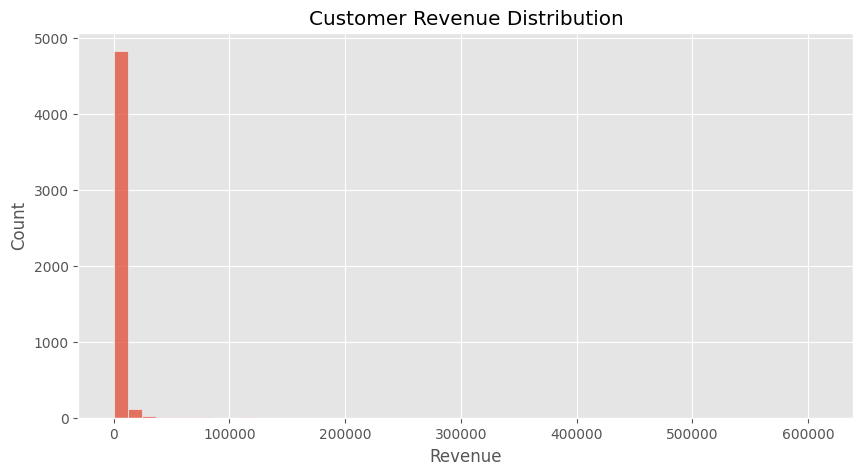

In [20]:
sample_customer = customer_revenue.sample(
    n=min(5000, len(customer_revenue)),
    random_state=42
)

plt.figure(figsize=(10,5))

sns.histplot(
    sample_customer,
    bins=50
)

plt.title(
    "Customer Revenue Distribution"
)

plt.show()

# Customer Analysis

Customer-level analysis helps understand:

- Customer spending behavior
- High-value customers
- Revenue concentration among customers

This information will support customer segmentation and churn prediction models.

## Key Findings

- Most customers generate relatively small revenue.
- A small percentage of customers contribute a large share of total revenue.
- High-value customers should be prioritized for retention strategies.

In [21]:
orders_per_customer = (df.groupby("Customer ID")["Invoice"].nunique())

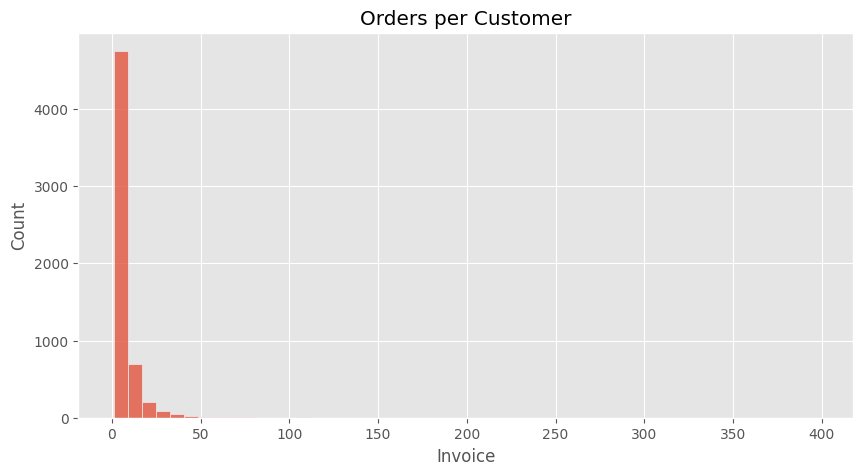

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(
    orders_per_customer,
    bins=50
)

plt.title(
    "Orders per Customer"
)

plt.show()

# Order Frequency Analysis

This section examines how often customers place orders.

The objective is to identify:

- Repeat purchase behavior
- Customer loyalty patterns
- Order frequency distribution

## Key Findings

- Most customers place only a few orders.
- A smaller group of customers purchases frequently.
- Frequent customers represent important long-term business value.

In [23]:
print("Total Customers:",
      df["Customer ID"].nunique())

print("Total Products:",
      df["StockCode"].nunique())

print("Total Orders:",
      df["Invoice"].nunique())

print("Total Revenue:",
      round(df["Revenue"].sum(),2))

Total Customers: 5878
Total Products: 4631
Total Orders: 36969
Total Revenue: 17743429.18


# Business Summary

## Dataset Statistics

- Total Customers: 5,878
- Total Products: 4,631
- Total Orders: 36,969
- Total Revenue: £17.74 Million

## Overall Findings

1. The business generated over £17 million in revenue.
2. The United Kingdom contributes the majority of revenue.
3. Revenue is concentrated among a small number of products.
4. Customer spending behavior is highly skewed.
5. A small group of loyal customers contributes significantly to overall revenue.

These insights form the foundation for subsequent machine learning tasks such as customer segmentation, churn prediction, revenue forecasting, and inventory optimization.

# NeuralRetail - Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to understand customer purchasing behavior, sales performance, product trends, and geographic revenue distribution before building machine learning models.

The analysis focuses on:

- Revenue Analysis
- Customer Analysis
- Product Analysis
- Country-wise Performance
- Sales Trends
- Business Insights

Dataset: Online Retail II
Period: December 2009 – December 2011

# Dataset Overview

This dataset contains transactional records from an online retail company.

### Key Attributes

- Invoice
- StockCode
- Description
- Quantity
- InvoiceDate
- Price
- Customer ID
- Country
- Revenue (engineered feature)

After preprocessing and cleaning, the dataset is used for customer segmentation, churn prediction, and forecasting.

# Revenue Analysis

Revenue is one of the most important business metrics.

In this section, we analyze:

- Total revenue generated
- Revenue distribution
- Revenue concentration patterns

This helps identify whether sales are evenly distributed or dominated by a small number of transactions.

## Revenue Distribution

The distribution of revenue helps identify:

- Typical transaction values
- High-value purchases
- Revenue outliers

Retail datasets usually show a long-tail distribution where most transactions are small while a few transactions contribute significantly to total revenue.

# Country-wise Revenue Analysis

Understanding geographic performance helps identify:

- Primary revenue sources
- International markets
- Expansion opportunities

Country-level analysis provides insights into customer demand across different regions.